<a href="https://colab.research.google.com/github/brainExplorer/python-data-visualization/blob/main/house_price_dataset_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
libraries = {
    "numpy": "import numpy as np",
    "pandas": "import pandas as pd",
    "regular_expression": "import re",
    "time": "import time",
    "matplotlib": "import matplotlib.pyplot as plt",
    "seaborn": "import seaborn as sns",
    "preprocessing": "from sklearn.preprocessing import OneHotEncoder, StandardScaler",
    "model_selection": "from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold",
    "linear_model": "from sklearn.linear_model import LinearRegression",
    "simple_imputer": "from sklearn.impute import SimpleImputer",
    "metrics": "from sklearn.metrics import mean_squared_error, r2_score",
    "tree": "from sklearn.tree import DecisionTreeRegressor",
    "ensemble": "from sklearn.ensemble import RandomForestRegressor",
    "neighbors": "from sklearn.neighbors import KNeighborsRegressor",
    "xgboost": "import xgboost as xgb",
    'pipeline': "from sklearn.pipeline import Pipeline",
    'google file': "from google.colab import files",
    'locale': "import locale",
    'datetime': "import datetime",
    'fg_profile': 'from data_profiling import ProfileReport'
}

for text, code in libraries.items():
    try:
        exec(code)
        print(f"✅ {text} imported")
    except ImportError as e:
        print(f"❌ {text} not imported (ImportError: {e})")
    except ModuleNotFoundError as e:
        print(f"❌ {text} not found (ModuleNotFoundError: {e})")
    except Exception as e:
        print(f"⚠️ {text} import failed: {e}")

✅ numpy imported
✅ pandas imported
✅ regular_expression imported
✅ time imported
✅ matplotlib imported
✅ seaborn imported
✅ preprocessing imported
✅ model_selection imported
✅ linear_model imported
✅ simple_imputer imported
✅ metrics imported
✅ tree imported
✅ ensemble imported
✅ neighbors imported
✅ xgboost imported
✅ pipeline imported
✅ google file imported
✅ locale imported
✅ datetime imported
✅ fg_profile imported


In [ ]:
# Dictionary to applying Turkish months name to English months
TURKISH_MONTHS = {
    'Ocak': 'January',
    'Şubat': 'February',
    'Mart': 'March',
    'Nisan': 'April',
    'Mayıs': 'May',
    'Haziran': 'June',
    'Temmuz': 'July',
    'Ağustos': 'August',
    'Eylül': 'September',
    'Ekim': 'October',
    'Kasım': 'November',
    'Aralık': 'December'
}

In [ ]:

def clean_price(price_str):
  """ Cleaning the price column: TL, comma, arrow signs, percentage signs remove """
  if pd.isna(price_str):
    return np.nan
  # Remove 'TL'
  price_str = str(price_str).replace('TL','').strip()
  # Remove 'arrow_downward%3'
  price_str = re.sub(r'arrow_downward%3', '', price_str)
  # A comma can be a thousands separator, and a dot can be a decimal separator.
  price_str = price_str.replace(',', '')

  # Convert the remaining number to float
  try:
    return float(price_str)
  except:
    return np.nan

In [ ]:
def clean_square_meters(val):
  """Removes 'm2' and spaces from square meter values, converting them to float."""
  if pd.isna(val):
    return np.nan
  val = str(val).replace('m2', '').strip()
  try:
    return float(val)
  except:
    return np.nan

In [ ]:
def clean_building_age(val):
  """Building age is adjusted as follows: '21 and above' -> 21, '0 (New)' -> 0, non-numeric values ​​are NaN."""
  if pd.isna(val):
    return np.nan
  val = str(val).strip()
  if 'Ve Üzeri' in val:
    # catch the number
    num = re.search(r'\d+', val)
    if num:
      return int(num.group())
  if 'Yeni' in val:
    return 0
  # can be a direct number
  try:
    return int(val)
  except:
    return np.nan

In [ ]:
def clean_date(date_str):
  """It translates the date format from Turkish to English and converts it into a datetime object."""
  if pd.isna(date_str):
    return np.nan
  # Convert Turkish to English
  for tr, en in TURKISH_MONTHS.items():
    if tr in date_str:
      date_str = date_str.replace(tr, en)
      break
  # Convert to datetime
  try:
    return pd.to_datetime(date_str, format='%d %B %Y')
  except:
    return np.nan

In [ ]:
def clean_rooms(val):
  """Standardizes the number of rooms: like '3+1', take only the number part or keep the '+' sign."""
  if pd.isna(val):
    return np.nan
  val = str(val).strip()
  if val == '':
    return np.nan
  return val

In [ ]:
def clean_floor_location(val):
  """Edits floor information: Texts like 'Çatı katı', 'bakçe Katı' can remain."""
  if pd.isna(val):
    return np.nan
  val = str(val).strip()
  if val == '':
    return np.nan
  return val

In [ ]:
def clean_heating(val):
  """It standardizes the type of heating."""
  if pd.isna(val):
    return np.nan
  val = str(val).strip()
  if val == '':
    return np.nan
  return val

In [ ]:
def clean_boolean(val):
  """It standardizes boolean columns like Yes/No."""
  if pd.isna(val):
    return np.nan
  val = str(val).strip().lower()
  if val == '':
    return np.nan
  if val in ['evet', 'true', '1', 'yes']:
    return 1
  elif val in ['hayır', 'false', '0', 'no']:
    return 0
  else:
    return np.nan


## Load the file

In [ ]:
loaded_file = files.upload()

Saving HouseData.csv to HouseData.csv


In [ ]:
# Read .csv file(encoding='utf-8' to Turkish chars)
df = pd.read_csv(list(loaded_file.keys())[0], encoding='utf-8', index_col=0)
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

In [ ]:
print(f'Data size: {df.shape}')
print(f'First 5 rows:\n{df.head()}')
print(f'Last 5 rows:\n{df.tail()}')

Data size: (25155, 37)
First 5 rows:
  district         price                                            address  \
0   adalar   3,100,000TL  ['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...   
1   adalar   1,600,000TL  ['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...   
2   adalar  18,500,000TL  ['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...   
3   adalar   9,500,000TL  ['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...   
4   adalar  25,000,000TL  ['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...   

    AdUpdateDate Category GrossSquareMeters  BuildingAge  \
0  24 Şubat 2022  Satılık            160 m2  21 Ve Üzeri   
1   02 Mart 2022  Satılık            120 m2         5-10   
2  11 Şubat 2022  Satılık            350 m2  21 Ve Üzeri   
3  11 Şubat 2022  Satılık            550 m2        11-15   
4   19 Ocak 2022  Satılık            840 m2  21 Ve Üzeri   

   NumberFloorsofBuilding           UsingStatus EligibilityForInvestment  ...  \
0                       3  Mülk Sahibi Oturuyo

In [ ]:

data_profile_report = ProfileReport(df, title="Pandas Profiling Report")
data_profile_report.to_file("data_profile_report.html")
files.download('data_profile_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 37/37 [00:05<00:00,  6.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def standardize_column_name(col):
  """
    Standardizes column names:
    - Converts to lowercase
    - Converts spaces and special characters to underscores
    - Removes leading and trailing underscores
    - Reduces multiple underscores to a single underscore
  """
  col = col.strip().lower()
  col = re.sub(r'[^\w\s]','',col)
  col = re.sub(r'\s+', '_', col)
  col = re.sub(r'-+','',col)
  col = col.strip('_')
  return col

In [ ]:
new_columns = {old_col: standardize_column_name(old_col) for old_col in df.columns}
df.rename(columns=new_columns, inplace=True)
print(f"Name of the standardized columns: {df.columns.tolist()}")

Name of the standardized columns: ['district', 'price', 'address', 'adupdatedate', 'category', 'grosssquaremeters', 'buildingage', 'numberfloorsofbuilding', 'usingstatus', 'eligibilityforinvestment', 'buildstatus', 'titlestatus', 'itemstatus', 'numberofbathrooms', 'numberofwcs', 'adcreationdate', 'type', 'netsquaremeters', 'numberofrooms', 'floorlocation', 'heatingtype', 'crediteligibility', 'insidethesite', 'structuretype', 'mortgagestatus', 'swap', 'balcony', 'pricestatus', 'rentalincome', 'numberofbalconies', 'balconytype', 'hallsquaremeters', 'wcsquaremeters', 'isitvideonavigable', 'subscription', 'bathroomsquaremeters', 'balconysquaremeters']


In [ ]:
# Clean the price
df['price'] = df['price'].apply(clean_price)

#Square meter cleaning (gross and net)
for col in ['grosssquaremeters', 'netsquaremeters']:
  if col in df.columns:
    df[col] = df[col].apply(clean_square_meters)

# Building age cleaning
if 'buildingage' in df.columns:
  df['buildingage'] = df['buildingage'].apply(clean_building_age)

# Dates
for col in ['adupdatedate', 'adcreationdate']:
    if col in df.columns:
        df[col] = df[col].apply(clean_date)

# Number of rooms (categorically protected)
if 'numberofrooms' in df.columns:
  df['numberofrooms'] = df['numberofrooms'].apply(clean_rooms).astype(str).str.strip()

# Floor information, heating type
for col in ['floorlocation', 'heatingtype']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()


# Boolean columns (standardized names)
bool_cols = ['insidethesite', 'swap', 'balcony', 'isitvideonavigable', 'subscription']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_boolean)

# Other num columns
numeric_cols = ['numberofbathrooms', 'numberofwcs', 'numberofbalconies',
                'hallsquaremeters', 'wcsquaremeters', 'bathroomsquaremeters', 'balconysquaremeters']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical cols
categorical_cols = ['district', 'category', 'usingstatus', 'eligibilityforinvestment',
                    'buildstatus', 'titlestatus', 'itemstatus', 'type',
                    'crediteligibility', 'structuretype', 'mortgagestatus',
                    'pricestatus', 'rentalincome', 'balconytype']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [ ]:
# Incomplete data management (numeric -> median, categorical -> mode, boolean -> 0)
# Numeric columns (previously cleared)
numeric_clean = ['price', 'grosssquaremeters', 'netsquaremeters', 'buildingage'] + numeric_cols
for col in numeric_clean:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Categorical columns (fill with mod)
categorical_clean = categorical_cols + ['floorlocation', 'heatingtype', 'numberofrooms']
for col in categorical_clean:
    if col in df.columns:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)


# Boolean columns (fill with 0)
for col in bool_cols:
    if col in df.columns:
        df[col].fillna(0, inplace=True)

/tmp/ipykernel_3066/2937795653.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_3066/2937795653.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [ ]:
df.head(20)

,district,price,address,adupdatedate,category,grosssquaremeters,buildingage,numberfloorsofbuilding,usingstatus,eligibilityforinvestment,...,pricestatus,rentalincome,numberofbalconies,balconytype,hallsquaremeters,wcsquaremeters,isitvideonavigable,subscription,bathroomsquaremeters,balconysquaremeters
0,adalar,3100000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-24,Satılık,160.0,21.0,3,Mülk Sahibi Oturuyor,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
1,adalar,1600000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-03-02,Satılık,120.0,2.0,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
2,adalar,18500000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2022-02-11,Satılık,350.0,21.0,2,Mülk Sahibi Oturuyor,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
3,adalar,9500000.0,"['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",2022-02-11,Satılık,550.0,2.0,3,Mülk Sahibi Oturuyor,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
4,adalar,25000000.0,"['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",2022-01-19,Satılık,840.0,21.0,4,Boş,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
5,adalar,7000000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2022-01-17,Satılık,200.0,21.0,2,Boş,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
6,adalar,3250000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-27,Satılık,400.0,21.0,3,Kiracı Oturuyor,nan,...,Genel Fiyat,12.000 TL,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
7,adalar,2850000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-22,Satılık,250.0,21.0,2,Boş,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
8,adalar,8350000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2021-12-16,Satılık,360.0,21.0,2,Boş,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN
9,adalar,10800000.0,"['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",2021-12-16,Satılık,180.0,21.0,2,Boş,Bilinmiyor,...,Genel Fiyat,nan,1.0,nan,NaN,NaN,0.0,0.0,NaN,NaN


In [ ]:
df.to_csv('cleaned.csv', index=False, encoding='utf-8-sig')
#files.download('cleaned.csv')

In [ ]:

def suggest_drop_columns(df, null_threshold=0.6, unique_threshold=2):
    """
    Analyzes the columns of a given DataFrame and returns a list of columns
    recommended for removal based on specific data quality rules.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        null_threshold (float): Columns with a null ratio above this value (0-1) will be flagged.
        unique_threshold (int): Columns with a number of distinct values less than or equal to this will be flagged.

    Returns:
        list: A list of column names recommended for dropping.
    """
    drop_cols = []

    for col in df.columns:
        # 1. Check for excessive missing values
        null_ratio = df[col].isnull().sum() / len(df)
        if null_ratio > null_threshold:
            drop_cols.append(col)
            continue

        # 2. Check for constant or near-constant values (too few unique values)
        unique_count = df[col].nunique(dropna=False)
        if unique_count <= unique_threshold:
            drop_cols.append(col)
            continue

        # 3. Check for complex data structures like lists, dicts, or tuples (difficult to parse)
        if df[col].dtype == 'object':
            # Sample the first non-null value to check its type
            sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
            if isinstance(sample, (list, tuple, dict)):
                drop_cols.append(col)
                continue

        # 4. (Optional) Automatically drop columns related to IDs or URLs if they add no value.
        # Uncomment the lines below if you want to use this rule.
        # if 'id' in col.lower() or 'url' in col.lower():
        #     drop_cols.append(col)
        #     continue

    return drop_cols

# Load your CSV file
df = pd.read_csv('cleaned.csv')

# Get the suggested columns to drop
cols_to_drop = suggest_drop_columns(df)
print("Suggested columns to drop:", cols_to_drop)

# Remove the columns
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Remaining columns: {df.shape[1]}")

Suggested columns to drop: ['category', 'titlestatus', 'type', 'insidethesite', 'mortgagestatus', 'swap', 'balcony', 'pricestatus', 'rentalincome', 'balconytype', 'hallsquaremeters', 'wcsquaremeters', 'isitvideonavigable', 'subscription', 'bathroomsquaremeters', 'balconysquaremeters']
Remaining columns: 21


## Step 1: Exploratory Data Analysis (EDA)
###View Target variable

Examine the distribution of the price variable. Here, if the skewness is greater than 1, a log transformation will be applied, reducing the influence of outliers on the majority values. This will make it suitable for linear regression and neural networks.

Note: To calculate the actual price in Turkish Lira (TL) in the predictions, you should apply the inverse of log1p, 'np.expm1'.

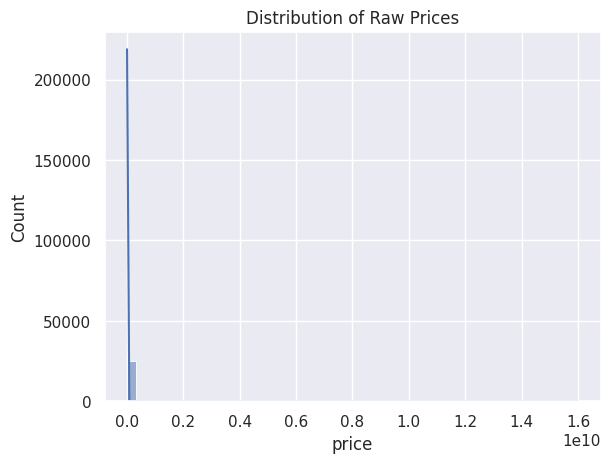

In [ ]:
# Distribution of raw prices
sns.set_theme(style='darkgrid')
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Distribution of Raw Prices')
plt.show()

In [ ]:
print(f'Skewness: {df["price"].skew()}')

Skewness: 139.18338857739445


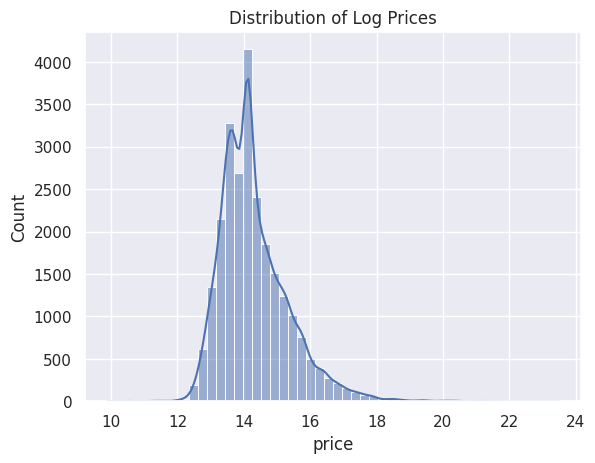

In [ ]:
log_price = np.log1p(df['price'])
sns.histplot(log_price, kde=True, bins=50)
plt.title('Distribution of Log Prices')
plt.show()

In [ ]:
print(f'Skewness: {log_price.skew()}')

Skewness: 1.2008752957801652


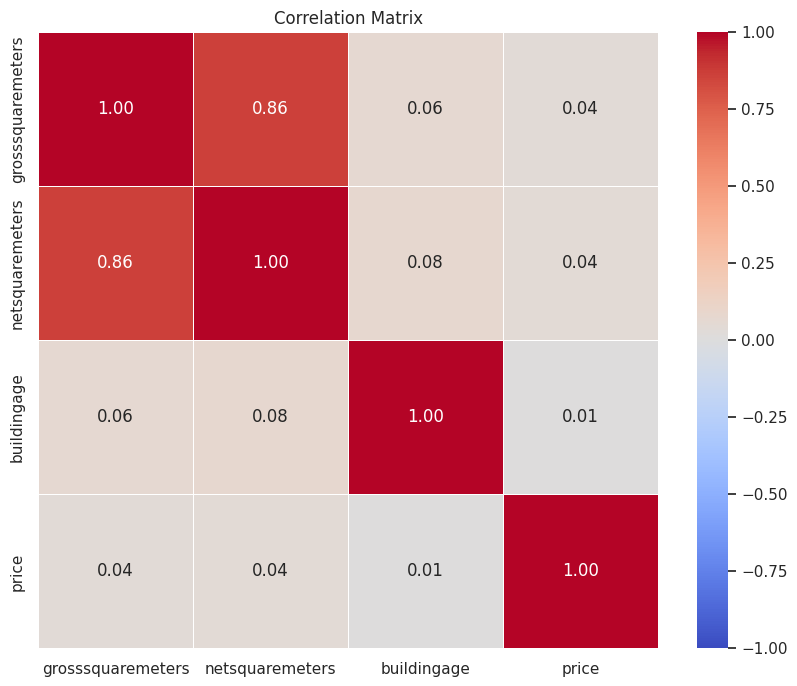

In [ ]:
selected_columns = ["grosssquaremeters", "netsquaremeters", "buildingage"]
target_column = "price"

columns_to_plot = selected_columns + [target_column]

correlation_matrix = df[columns_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

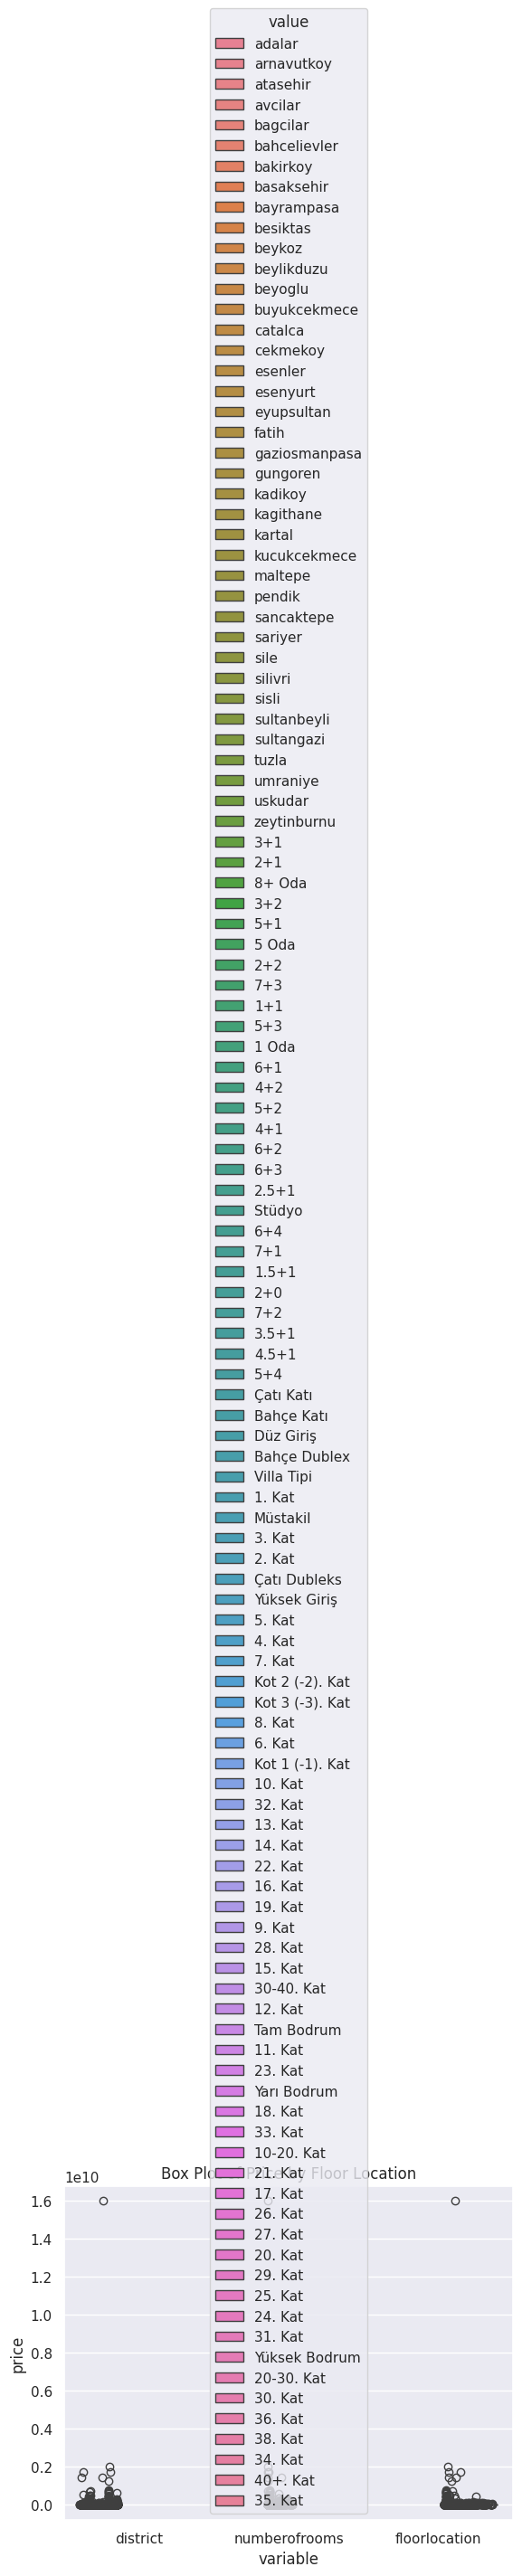

In [ ]:
# We convert the desired columns to long format by combining them with 'price'.
melted_df = pd.melt(df, id_vars=['price'], value_vars=["district", "numberofrooms", "floorlocation"])
sns.boxplot(data=melted_df, x="variable", y="price", hue="value")
plt.title('Box Plot of Price by Floor Location')
plt.show()

In [ ]:
df.head(15)

,district,price,address,adupdatedate,grosssquaremeters,buildingage,numberfloorsofbuilding,usingstatus,eligibilityforinvestment,buildstatus,...,numberofbathrooms,numberofwcs,adcreationdate,netsquaremeters,numberofrooms,floorlocation,heatingtype,crediteligibility,structuretype,numberofbalconies
0,adalar,3100000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-24,160.0,21.0,3,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,...,2.0,1.0,2022-02-24,120.0,3+1,Çatı Katı,Kombi Doğalgaz,Krediye Uygun,NaN,1.0
1,adalar,1600000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-03-02,120.0,2.0,3,Mülk Sahibi Oturuyor,Yatırıma Uygun,İkinci El,...,1.0,1.0,2022-02-21,100.0,2+1,Bahçe Katı,Kombi Doğalgaz,Krediye Uygun,Betonarme,1.0
2,adalar,18500000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2022-02-11,350.0,21.0,2,Mülk Sahibi Oturuyor,Bilinmiyor,NaN,...,3.0,1.0,2022-02-11,300.0,3+1,Düz Giriş,Kombi Doğalgaz,Krediye Uygun,NaN,1.0
3,adalar,9500000.0,"['Anasayfa', 'Satılık Bina', 'İstanbul Satılık...",2022-02-11,550.0,2.0,3,Mülk Sahibi Oturuyor,Bilinmiyor,İkinci El,...,4.0,1.0,2022-02-03,540.0,8+ Oda,Düz Giriş,Kombi Doğalgaz,Krediye Uygun Değil,Betonarme,1.0
4,adalar,25000000.0,"['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",2022-01-19,840.0,21.0,4,Boş,Bilinmiyor,İkinci El,...,3.0,1.0,2022-01-19,700.0,8+ Oda,Düz Giriş,Isıtma Yok,Krediye Uygun,Ahşap,1.0
5,adalar,7000000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2022-01-17,200.0,21.0,2,Boş,Bilinmiyor,NaN,...,1.0,1.0,2022-01-17,170.0,3+2,Düz Giriş,Isıtma Yok,Krediye Uygun,NaN,1.0
6,adalar,3250000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-27,400.0,21.0,3,Kiracı Oturuyor,NaN,NaN,...,5.0,1.0,2022-01-12,370.0,8+ Oda,Bahçe Dublex,Sobalı,Krediye Uygun,NaN,1.0
7,adalar,2850000.0,"['Anasayfa', 'Satılık Daire', 'İstanbul Satılı...",2022-02-22,250.0,21.0,2,Boş,Bilinmiyor,NaN,...,2.0,1.0,2022-01-11,200.0,5+1,Villa Tipi,Isıtma Yok,Krediye Uygun,NaN,1.0
8,adalar,8350000.0,"['Anasayfa', 'Satılık Müstakil Ev', 'İstanbul ...",2021-12-16,360.0,21.0,2,Boş,Bilinmiyor,NaN,...,2.0,1.0,2021-12-16,240.0,5+1,Düz Giriş,Kombi Doğalgaz,Krediye Uygun,NaN,1.0
9,adalar,10800000.0,"['Anasayfa', 'Satılık Köşk', 'İstanbul Satılık...",2021-12-16,180.0,21.0,2,Boş,Bilinmiyor,NaN,...,1.0,1.0,2021-12-16,140.0,5 Oda,Düz Giriş,Kombi Doğalgaz,Krediye Uygun,Ahşap,1.0


##Step 2: Feature Engineering
  - Square Meters: `price_per_sqm = price / netsquaremeters` (it is very good for both analysis and outlier detection).

  - Usage Rate: `usable_ratio = netsquaremeters / grosssquaremeters` (The gross rate of the aura gives an idea about building quality).

- Floor Info: "Garden" in floorlocation, "Roof" and "Roof" phrases such as "ground", "middle" and "ball" and create a new categorical column.

- Building Age Groups: Dividing buildingage into slices such as "0-5 years", "5-15 years" and "15+ years."

In [ ]:
def extract_floor_number(row):
    """
    Analyzes the 'floorlocation' text and returns the floor number as an integer.
    Returns NaN if the floor number cannot be determined.
    """
    text = row['floorlocation']
    total_floors = row['numberfloorsofbuilding']

    # Check if the text is missing
    if pd.isna(text):
        return np.nan

    text = str(text)

    # A) Special case: "Kot 2 (-2). Kat"
    # Extract the negative floor number inside parentheses (e.g., -2)
    kot_match = re.search(r'\(\s*(-?\d+)\s*\)', text)
    if kot_match:
        return int(kot_match.group(1))

    # B) Standard pattern: "X. Kat" (e.g., 1. Kat, 5. Kat)
    kat_match = re.search(r'(\d+)\.\s*Kat', text)
    if kat_match:
        return int(kat_match.group(1))

    # C) If the text contains "Dubleks" (Duplex) or "Çatı" (Roof),
    # assume it is located on the top floor.
    # If the total number of floors is available, use it.
    # Otherwise, assign 99 as an indicator of an unknown top floor.
    if 'dubleks' in text.lower() or 'çatı' in text.lower():
        if pd.notna(total_floors) and total_floors > 0:
            return total_floors
        else:
            return 99

    # D) "Bahçe Katı" (Garden Floor), "Zemin" (Ground Floor),
    # or "Düz Giriş" (Direct Entrance) are treated as ground level (0).
    if (
        'bahçe' in text.lower()
        or 'zemin' in text.lower()
        or 'düz giriş' in text.lower()
    ):
        return 0

    # E) Basement floors are generally treated as ground level (0)
    # because the exact basement level is usually unknown.
    if 'bodrum' in text.lower():
        return 0

    # Return NaN if none of the patterns match
    return np.nan


# Create a new column containing the extracted floor number
df['floor_number'] = df.apply(extract_floor_number, axis=1)


# --- STEP 2: Categorize Floors into Ground, Middle, and Top ---
def categorize_floor(row):
    """
    Categorizes the floor into 'ground', 'middle', or 'top'
    based on the extracted floor number and the total number of floors.
    """
    floor_num = row['floor_number']
    total_floors = row['numberfloorsofbuilding']

    # Return 'unknown' if the required information is missing or invalid
    if pd.isna(floor_num) or pd.isna(total_floors) or total_floors <= 0:
        return 'unknown'

    # Calculate the floor ratio
    ratio = floor_num / total_floors

    # Categorize using predefined thresholds
    if ratio <= 0.33:
        return 'ground'      # Lower floors
    elif ratio <= 0.66:
        return 'middle'      # Middle floors
    else:
        return 'top'         # Upper floors

In [ ]:
price_per_sqm = df['price'] / df['netsquaremeters']
df['price_per_sqm'] = price_per_sqm

usable_ratio = df['netsquaremeters'] / df['grosssquaremeters']
df['usable_ratio'] = usable_ratio

df['building_age_group'] = pd.cut(
    df['buildingage'],
    bins=[0, 5, 15, np.inf],
    labels=['0-5 years', '5-15 years', '15+ years']
)

# Create the categorical floor column
df['floor_category'] = df.apply(categorize_floor, axis=1)


# --- Optional: Display the results for verification ---
print(
    df[
        [
            'floorlocation',
            'floor_number',
            'numberfloorsofbuilding',
            'floor_category'
        ]
    ].head(20)
)

   floorlocation  floor_number  numberfloorsofbuilding floor_category
0      Çatı Katı           3.0                       3            top
1     Bahçe Katı           0.0                       3         ground
2      Düz Giriş           0.0                       2         ground
3      Düz Giriş           0.0                       3         ground
4      Düz Giriş           0.0                       4         ground
5      Düz Giriş           0.0                       2         ground
6   Bahçe Dublex           0.0                       3         ground
7     Villa Tipi           NaN                       2        unknown
8      Düz Giriş           0.0                       2         ground
9      Düz Giriş           0.0                       2         ground
10        1. Kat           1.0                       3         middle
11     Düz Giriş           0.0                       2         ground
12     Düz Giriş           0.0                       3         ground
13     Düz Giriş    

##Step 3: Data Pre-processing and Pipeline Preparation
Instead of manually transforming the numerical data used in model feeding, we ensure transformations by using Scikit-Learn Pipeline and ColumnTransformer.

In [ ]:
numerical_features = ['grosssquaremeters', 'netsquaremeters', 'buildingage',
                      'price_per_sqm', 'usable_ratio', 'floor_number']
categorical_features = ['district', 'numberofrooms', 'floor_category',
                        'heatingtype', 'crediteligibility', 'usingstatus',
                        'building_age_group']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

##Step 4: Train Model
Split the data as train and test. Target value is 'price'.

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Hedef değişkeni log dönüşümü ile dönüştürelim
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'XGBoost': xgb.XGBRegressor()
}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train_log)
    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)          # Gerçek fiyata dönüştür
    print(f'{name} R2: {r2_score(y_test, y_pred)}')
    print(f'{name} RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

Linear Regression R2: -210.8688613717749
Linear Regression RMSE: 447791141.92700094
Decision Tree R2: 0.8786057492809618
Decision Tree RMSE: 10718672.24698172
Random Forest R2: 0.8594459206410673
Random Forest RMSE: 11533567.43862452
K-Nearest Neighbors R2: 0.1302919425156721
K-Nearest Neighbors RMSE: 28689876.500201974
XGBoost R2: -11.710841989167246
XGBoost RMSE: 109680416.73901582


##Step 5: Hyperparameter Optimization
Select the best performance model (probably XGBoost or RandomForest) and fine-tune parameters with RandomizedSearchCV.

In [ ]:
param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__max_depth' : [3,6,10],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}
xgb_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', xgb.XGBRegressor())])
search = RandomizedSearchCV(xgb_pipe, param_grid, n_iter=20, cv=5, scoring='r2',
                            random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_pipe = search.best_estimator_
feature_names = get_feature_names(best_pipe.named_steps['preprocessor'])
model = best_pipe.named_steps['regressor']

best_pipe = search.best_estimator_
y_pred_log = best_pipe.predict(X_test)
y_pred = np.expm1(y_pred_log)
print(f'Test R2: {r2_score(y_test, y_pred)}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

Test R2: 0.5692552197135097
Test RMSE: 20190726.393127397


##Step 6: Visualization and Reporting Results
Draw a scatter plot comparing actual prices with predicted prices.

Examine the residuals.

Visualize which features have the greatest impact on price using RandomForest or XGBoost.

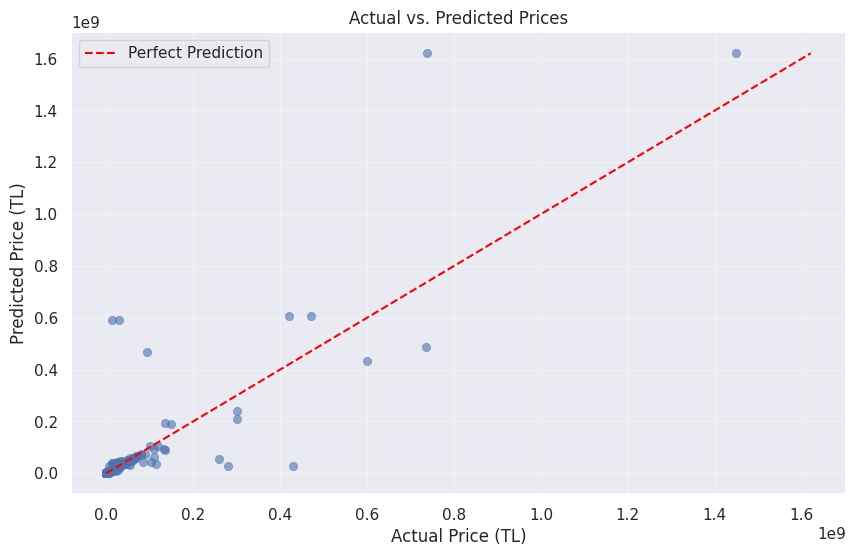

In [ ]:
# Real vs Predicted Price (scatter plot)
y_pred = search.predict(X_test)

# Since the model was trained on raw price, no transformation is needed.
y_test_actual = y_test   # keep original
y_pred_actual = y_pred

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_actual, y=y_pred_actual, alpha=0.6, edgecolor=None)

# Diagonal line (perfect prediction)
max_val = max(max(y_test_actual), max(y_pred_actual))
min_val = min(min(y_test_actual), min(y_pred_actual))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (TL)')
plt.ylabel('Predicted Price (TL)')
plt.title('Actual vs. Predicted Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Error Distribution (Residuals) Analysis

We examine whether the errors (i.e., the difference between the actual result and the prediction) are symmetrical around 0. If the errors are normally distributed, it means the model is making a good prediction.

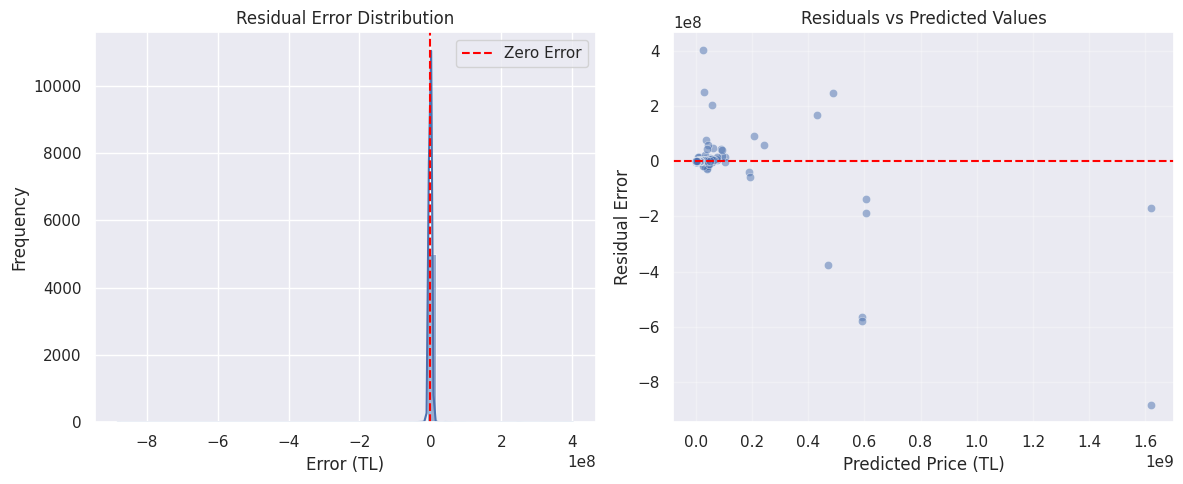

In [ ]:
# Calculate residuals (prediction errors)
residuals = y_test_actual - y_pred_actual

# --- 2.a: Residuals Histogram ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, bins=50)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Error (TL)')
plt.ylabel('Frequency')
plt.title('Residual Error Distribution')
plt.legend()

# --- 2.b: Residuals vs Predicted Values (Heteroscedasticity Check) ---
# This plot helps determine whether prediction errors increase
# as the predicted house prices become larger.
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_actual, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price (TL)')
plt.ylabel('Residual Error')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance Analysis

This section identifies which features have the greatest influence on the predicted house prices.

Examples of important variables include:

- District
- Gross Square Footage
- Net Square Footage
- Building Age
- Floor Number
- Number of Rooms
- Heating Type

Feature importance can be analyzed using both **Random Forest** and **XGBoost** models.

---

## Critical Step: Extracting Feature Names from the Pipeline

Since the preprocessing pipeline uses a **ColumnTransformer** together with **OneHotEncoder**, many categorical variables are transformed into multiple encoded columns.

Before plotting or interpreting feature importance, we first need to retrieve the complete list of transformed feature names from the pipeline.

This step ensures that each importance score is correctly matched with its corresponding feature.

In [ ]:
def get_feature_names(column_transformer):
    return column_transformer.get_feature_names_out()



/tmp/ipykernel_3066/1052626223.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette='viridis')


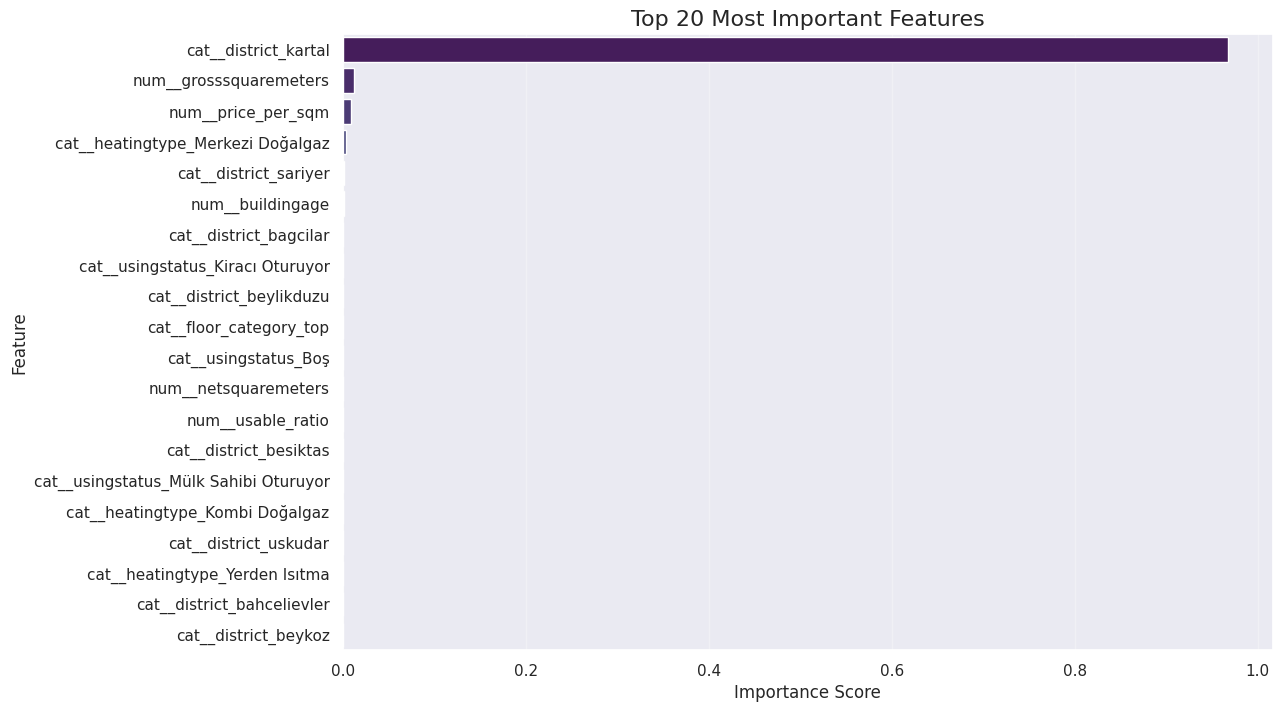


--- Top 10 Most Important Features ---
                              feature  importance
30               cat__district_kartal    0.968176
0              num__grosssquaremeters    0.011766
3                  num__price_per_sqm    0.008583
87  cat__heatingtype_Merkezi Doğalgaz    0.003154
35              cat__district_sariyer    0.001704
2                    num__buildingage    0.000846
10             cat__district_bagcilar    0.000806
95   cat__usingstatus_Kiracı Oturuyor    0.000797
17           cat__district_beylikduzu    0.000685
74            cat__floor_category_top    0.000681


In [ ]:
best_pipe = search.best_estimator_
feature_names = get_feature_names(best_pipe.named_steps['preprocessor'])
model = best_pipe.named_steps['regressor']

if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df.head(20), x='importance', y='feature', palette='viridis')
    plt.title('Top 20 Most Important Features', fontsize=16)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    print("\n--- Top 10 Most Important Features ---")
    print(feat_imp_df.head(10))
else:
    print("Bu model feature_importances_ desteklemiyor.")